In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=4):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.enc4 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.out_conv = nn.Conv2d(32, 4, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(e4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

model = UNet(in_channels=4, out_channels=4)
state_dict = torch.load('../models/best_model.pth', map_location='cpu', weights_only=False)
model.load_state_dict(state_dict)
model.eval()

print("✅ UNet loaded successfully")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ UNet loaded successfully
Parameters: 1,928,804


In [3]:
import h5py
import cv2

# Load the sample file
sample_path = "../data/volume_100_slice_0.h5"

with h5py.File(sample_path, "r") as f:
    print("Keys:", list(f.keys()))
    image = f["image"][:]
    mask = f["mask"][:]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Keys: ['image', 'mask']
Image shape: (240, 240, 4)
Mask shape: (240, 240, 3)


In [4]:
import numpy as np
import torch

IMG_SIZE = 128

# --- Preprocess (same as training) ---
image_proc = image.astype(np.float32).copy()
for c in range(image_proc.shape[-1]):
    ch = image_proc[:, :, c]
    mx = ch.max()
    if mx > 0:
        image_proc[:, :, c] = ch / mx

image_proc = cv2.resize(image_proc, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
image_tensor = torch.from_numpy(image_proc).permute(2, 0, 1).unsqueeze(0)  # (1, 4, 128, 128)

print("Input tensor shape:", image_tensor.shape)

# --- Run inference ---
with torch.no_grad():
    output = model(image_tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze(0).numpy()

print("Output shape:", output.shape)
print("Predicted mask shape:", pred_mask.shape)
print("Unique predicted classes:", np.unique(pred_mask))

Input tensor shape: torch.Size([1, 4, 128, 128])
Output shape: torch.Size([1, 4, 128, 128])
Predicted mask shape: (128, 128)
Unique predicted classes: [0]


Ground truth unique classes: [0]


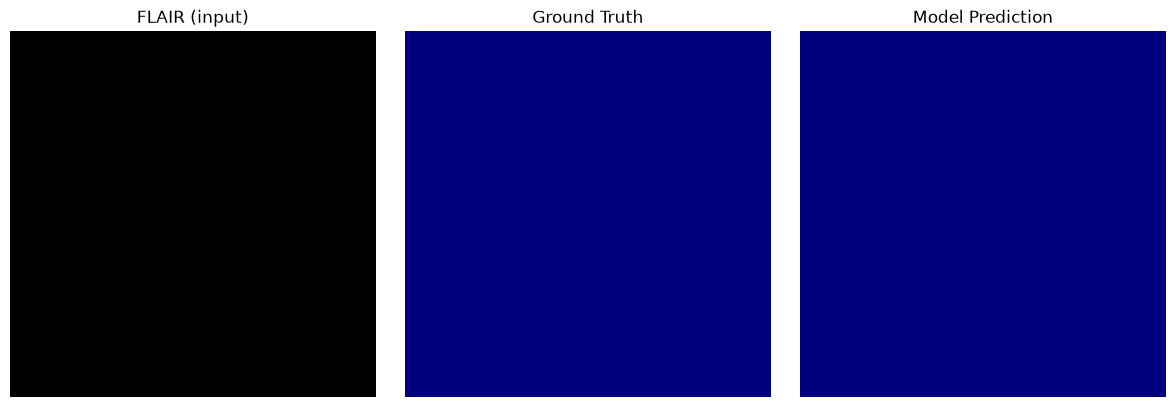

In [5]:
import matplotlib.pyplot as plt

# Check ground truth too
mask_resized = cv2.resize(mask.astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
gt_label = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.int64)
gt_label[mask_resized[:, :, 0] > 0.5] = 1
gt_label[mask_resized[:, :, 1] > 0.5] = 2
gt_label[mask_resized[:, :, 2] > 0.5] = 3

print("Ground truth unique classes:", np.unique(gt_label))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_proc[:, :, 3], cmap="gray")
axes[0].set_title("FLAIR (input)")
axes[1].imshow(gt_label, cmap="jet", vmin=0, vmax=3)
axes[1].set_title("Ground Truth")
axes[2].imshow(pred_mask, cmap="jet", vmin=0, vmax=3)
axes[2].set_title("Model Prediction")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
sample_path2 = "../data/volume_100_slice_64.h5"

with h5py.File(sample_path2, "r") as f:
    image2 = f["image"][:]
    mask2 = f["mask"][:]

print("Image shape:", image2.shape)
print("Mask shape:", mask2.shape)

# Preprocess
image2_proc = image2.astype(np.float32).copy()
for c in range(image2_proc.shape[-1]):
    ch = image2_proc[:, :, c]
    mx = ch.max()
    if mx > 0:
        image2_proc[:, :, c] = ch / mx

image2_proc = cv2.resize(image2_proc, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
image2_tensor = torch.from_numpy(image2_proc).permute(2, 0, 1).unsqueeze(0)

# Inference
with torch.no_grad():
    output2 = model(image2_tensor)
    pred_mask2 = torch.argmax(output2, dim=1).squeeze(0).numpy()

print("Predicted classes:", np.unique(pred_mask2))

# Ground truth for comparison
mask2_resized = cv2.resize(mask2.astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
gt_label2 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.int64)
gt_label2[mask2_resized[:, :, 0] > 0.5] = 1
gt_label2[mask2_resized[:, :, 1] > 0.5] = 2
gt_label2[mask2_resized[:, :, 2] > 0.5] = 3
print("Ground truth classes:", np.unique(gt_label2))

Image shape: (240, 240, 4)
Mask shape: (240, 240, 3)
Predicted classes: [0 1 2 3]
Ground truth classes: [0 1 2 3]


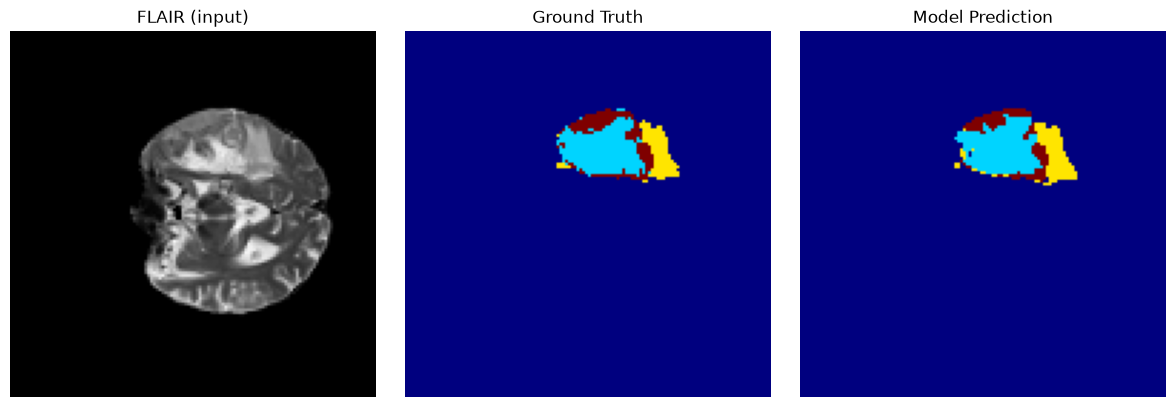

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image2_proc[:, :, 3], cmap="gray")
axes[0].set_title("FLAIR (input)")
axes[1].imshow(gt_label2, cmap="jet", vmin=0, vmax=3)
axes[1].set_title("Ground Truth")
axes[2].imshow(pred_mask2, cmap="jet", vmin=0, vmax=3)
axes[2].set_title("Model Prediction")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()